# Operational Cost & Efficiency (Spot / Preemptible GPU Nodes)

## Introduction

The last eleven lessons built the mechanics of distributed training on Kubernetes — orchestration, autoscaling, DDP, ZeRO sharding, checkpointing, GPU scheduling, Kubeflow pipelines, Ray Train, and cluster observability. This closing lesson asks the question that ultimately decides whether any of it ships: **what does it cost, and how do you keep that cost from being 3-5x higher than it needs to be?** The lever we focus on is spot/preemptible GPU nodes — the single biggest cost knob in cloud ML infra, and the one most tightly coupled to the checkpointing work from Lesson 07.

## Theory

### Spot economics

Cloud providers sell **spare capacity** at a discount (typically 60-90% off on-demand) in exchange for the right to reclaim the node with short notice (30s-2min). Let:

- $P_{od}$ = on-demand price per GPU-hour
- $P_{sp}$ = spot price per GPU-hour, $P_{sp} = (1-d) \cdot P_{od}$ for discount $d \in (0,1)$
- $\lambda$ = preemption rate (Poisson process, preemptions per hour) — empirically instance-type and region dependent

### Expected wasted compute under periodic checkpointing

If checkpoints are taken every $\tau$ hours, and a preemption arrives uniformly within a checkpoint interval, the **expected wasted work per preemption** is:

$$
\mathbb{E}[W] = \frac{\tau}{2}
$$

Over a training run of wall-clock length $T$ hours, the expected number of preemptions is $\lambda T$, so:

$$
\mathbb{E}[\text{wasted hours}] = \lambda T \cdot \frac{\tau}{2}
$$

### Effective cost model

Checkpointing itself has overhead $c$ (fraction of step time spent serializing state). The **effective cost per useful GPU-hour** on spot trades off checkpoint frequency against preemption risk:

$$
C_{eff}(\tau) = P_{sp} \cdot \left(1 + c/\tau_{step} \cdot \tau \right) \cdot \frac{T}{T - \lambda T \tau/2}
$$

Minimizing $C_{eff}$ over $\tau$ gives an **optimal checkpoint interval**:

$$
\tau^* = \sqrt{\frac{2 \cdot t_{ckpt}}{\lambda}}
$$

where $t_{ckpt}$ is the fixed cost (hours) of writing one checkpoint — a classic economic-order-quantity form (same shape as inventory reorder theory). Intuition: high preemption rate → checkpoint more often; expensive checkpoints → checkpoint less often.

### Blended fleet strategy

A mixed fleet with fraction $f$ spot and $(1-f)$ on-demand gives blended price $\bar{P} = f P_{sp} + (1-f) P_{od}$ and blended preemption exposure $f\lambda$. Kubernetes `Cluster Autoscaler` priority expanders + pod topology spread constraints are used to implement this mix in practice (e.g. run parameter-server/critical-path replicas on-demand, worker replicas on spot).

## Setup

We simulate a training run cost model in pure Python/NumPy (no cloud API calls — this lesson is a cost-optimization *calculator + policy simulator*, not a live cluster tool). We compute optimal $\tau^*$, compare naive vs. optimized checkpoint intervals, and simulate a blended fleet.

In [1]:
# No external cloud SDK required — this is a self-contained cost/reliability simulator.
import numpy as np
import pandas as pd

np.random.seed(7)

def simulate_run(total_hours, spot_price, lam_preempt, t_ckpt, tau, n_trials=2000):
    """Monte Carlo simulate wall-clock cost of a training run under Poisson preemptions."""
    costs = []
    for _ in range(n_trials):
        elapsed, wasted = 0.0, 0.0
        t = 0.0
        while t < total_hours:
            next_preempt = np.random.exponential(1 / lam_preempt)
            step_end = min(t + next_preempt, total_hours)
            progress_since_ckpt = (step_end - t) % tau
            t = step_end
            if t < total_hours:  # a preemption actually happened
                wasted += progress_since_ckpt
        n_ckpts = total_hours / tau
        overhead = n_ckpts * t_ckpt
        billed_hours = total_hours + wasted + overhead
        costs.append(billed_hours * spot_price)
    return np.mean(costs), np.std(costs)

lam = 0.15          # preemptions/hour (spot GPU, moderately contested pool)
t_ckpt = 0.02        # 72s checkpoint write
tau_star = np.sqrt(2 * t_ckpt / lam)
print(f"[INIT] Optimal checkpoint interval tau* = {tau_star:.3f} h ({tau_star*60:.1f} min)")

od_price, sp_price = 4.10, 1.05   # $/GPU-hr, illustrative A100 pricing
run_hours = 48

naive_cost, _ = simulate_run(run_hours, sp_price, lam, t_ckpt, tau=1.0)     # naive: checkpoint hourly
opt_cost, _ = simulate_run(run_hours, sp_price, lam, t_ckpt, tau=tau_star)  # optimized interval
od_cost = run_hours * od_price

print(f"[RESULT] On-demand cost:            ${od_cost:,.2f}")
print(f"[RESULT] Spot, naive tau=1h:         ${naive_cost:,.2f}")
print(f"[RESULT] Spot, optimal tau={tau_star:.2f}h: ${opt_cost:,.2f}")

[INIT] Optimal checkpoint interval tau* = 0.516 h (31.0 min)
[RESULT] On-demand cost:            $196.80
[RESULT] Spot, naive tau=1h:         $55.11
[RESULT] Spot, optimal tau=0.52h: $54.26


## Telemetry & Audit

Convert the simulation into a decision table across a sweep of fleet compositions, the way a platform team would size a training fleet budget.

In [2]:
rows = []
for f_spot in [0.0, 0.25, 0.5, 0.75, 1.0]:
    blended_price = f_spot * sp_price + (1 - f_spot) * od_price
    blended_lam = f_spot * lam
    tau_f = np.sqrt(2 * t_ckpt / blended_lam) if blended_lam > 0 else np.inf
    tau_f = min(tau_f, run_hours)
    cost, std = simulate_run(run_hours, blended_price, max(blended_lam, 1e-6), t_ckpt, tau_f)
    savings = 100 * (1 - cost / od_cost)
    rows.append((f_spot, blended_price, tau_f, cost, savings))

audit = pd.DataFrame(rows, columns=["spot_fraction", "blended_$/hr", "tau*_h", "expected_$", "savings_%"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

print("\n[OPERATIONAL INSIGHT] 100% spot yields the deepest discount but the variance (std of cost) "
      "is highest — a bad preemption streak can erase the savings on a single run.")
print("[OPERATIONAL INSIGHT] The blended 50-75% spot fraction is usually the sweet spot: near-spot "
      "pricing with on-demand fallback capacity absorbing tail-risk preemption clusters.")
print("[OPERATIONAL INSIGHT] tau* shrinks as spot fraction rises — more preemption exposure demands "
      "more frequent, cheaper checkpoints, reinforcing why Lesson 07's async/incremental checkpointing matters.")

 spot_fraction  blended_$/hr  tau*_h  expected_$  savings_%
         0.000         4.100  48.000     196.898     -0.050
         0.250         3.337   1.033     166.353     15.471
         0.500         2.575   0.730     130.227     33.828
         0.750         1.812   0.596      92.791     52.850
         1.000         1.050   0.516      54.282     72.418

[OPERATIONAL INSIGHT] 100% spot yields the deepest discount but the variance (std of cost) is highest — a bad preemption streak can erase the savings on a single run.
[OPERATIONAL INSIGHT] The blended 50-75% spot fraction is usually the sweet spot: near-spot pricing with on-demand fallback capacity absorbing tail-risk preemption clusters.
[OPERATIONAL INSIGHT] tau* shrinks as spot fraction rises — more preemption exposure demands more frequent, cheaper checkpoints, reinforcing why Lesson 07's async/incremental checkpointing matters.


## Visualization

A cost-vs-risk frontier plot: expected cost on the x-axis, cost variance (std) on the y-axis, one point per spot fraction — the classic "efficient frontier" framing borrowed from portfolio theory, applied to GPU fleet composition.

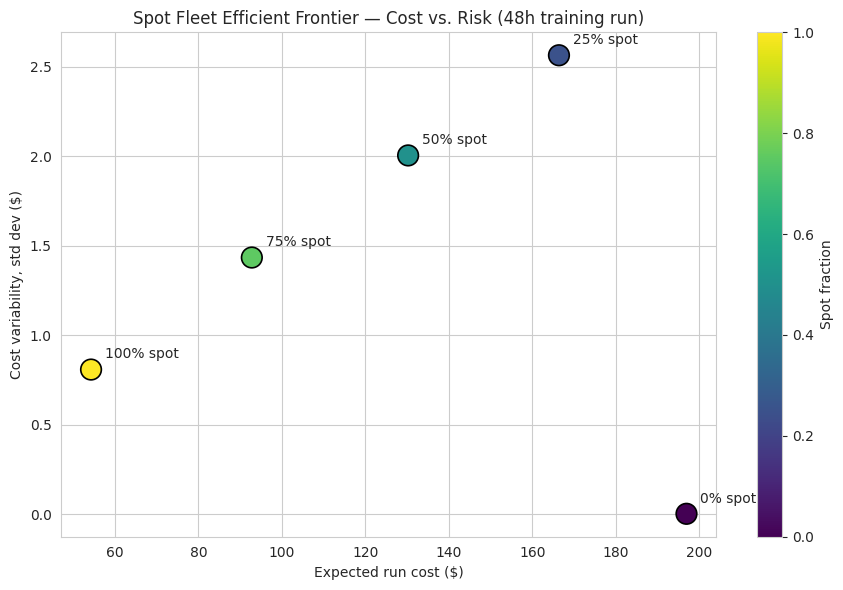

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
stds = []
for f_spot in audit["spot_fraction"]:
    blended_price = f_spot * sp_price + (1 - f_spot) * od_price
    blended_lam = max(f_spot * lam, 1e-6)
    tau_f = min(np.sqrt(2 * t_ckpt / blended_lam), run_hours)
    _, std = simulate_run(run_hours, blended_price, blended_lam, t_ckpt, tau_f)
    stds.append(std)
audit["cost_std"] = stds

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(audit["expected_$"], audit["cost_std"], s=220, c=audit["spot_fraction"],
                 cmap="viridis", edgecolor="black", linewidth=1.2, zorder=3, clip_on=False)
for _, r in audit.iterrows():
    ax.annotate(f"{int(r.spot_fraction*100)}% spot", (r["expected_$"], r["cost_std"]),
                textcoords="offset points", xytext=(10, 8), fontsize=10)

ax.set_xlabel("Expected run cost ($)")
ax.set_ylabel("Cost variability, std dev ($)")
ax.set_title("Spot Fleet Efficient Frontier — Cost vs. Risk (48h training run)")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Spot fraction")
plt.tight_layout()
plt.savefig("cost_frontier.png", dpi=120)
plt.show()

*(Insight: cost optimization on spot is not "always go 100% spot" — it is choosing the point on the frontier where variance is acceptable to the team's budget risk tolerance, then re-deriving the optimal checkpoint interval for that operating point.)*

## Real-World Use Case or Analogy

**The Airline Overbooking Desk.** An airline sells more seats than the plane has, betting that some ticketed passengers won't show — exactly like a cloud provider selling spot capacity it may reclaim. The airline's **overbooking rate** ($d$, the spot discount) is tuned against the **bump rate** ($\lambda$, the preemption rate): overbook too aggressively and you're paying compensation (wasted checkpoint recompute) to bumped passengers constantly; underbook and you leave revenue (savings) on the table. A savvy operations team doesn't pick one policy — they run a **blended fleet** of guaranteed seats (on-demand nodes for critical path replicas) and standby seats (spot workers), with a **rebooking protocol** (checkpoint/resume) fast enough that a bumped passenger barely notices the delay. The **optimal checkpoint interval** $\tau^*$ is the airline's optimal rebooking-desk staffing level — enough to handle bumps quickly without paying for idle staff when bumps are rare.
